# FEEDS vs Random — Statistical Analysis

Paired comparison of FEEDS-selected runs (**Dataset 111**) against the
corresponding randomly-selected runs (**Dataset 999**) on the held-out
**`test_predictions`** split.

**Fold → % labeled data mapping** (from the run bookkeeping):

| % labeled | 1% | 5% | 10% | 11% | 15% | 20% | 30% | 40% | 50% | 60% | 70% | 100% |
|-----------|----|----|-----|-----|-----|-----|-----|-----|-----|-----|-----|------|
| **999** (random) | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 | 10 | 11 |
| **111** (FEEDS)  |   |   | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |

So FEEDS `fold_k` lines up with random `fold_{k+2}` at the same labeling fraction.

Sections:
1. Setup & paths
2. Identify non-diseased cases
3. Loader (`load_dataset_folds_with_diagnosis`)
4. Plotting helper (`get_comparison`)
5. **FEEDS vs random paired tests on `test_predictions`** (the new analysis)
6. Visualization

## 1. Setup & paths

In [ ]:
%matplotlib inline

In [2]:
import os
import json
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# ------------------------------------------------------------------ paths
os.environ['nnUNet_results'] = "../../nnUNet_results/"
nnUNet_results = os.environ['nnUNet_results']

DEFAULT_SUMMARY_PATH = (
    "{nnUNet_results}/{input_dataset}/"
    "autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/"
    "{fold}/{validation}/summary.json"
).format(
    nnUNet_results=nnUNet_results,
    input_dataset="{input_dataset}",
    fold="{fold}",
    validation="{validation}",
)
print(DEFAULT_SUMMARY_PATH)


def read_summary_file(path, fold, validation):
    """Load a summary.json for one (fold, validation) pair."""
    with open(path.format(fold=fold, validation=validation), "r") as f:
        return json.load(f)


def convert_location_to_case_name(file_locations):
    """Map a DICOM 'File Location' path to its fdg_<id>_<scan> case name."""
    case_names = []
    for path in file_locations:
        parts = path.split('/')
        patient_id  = parts[2].replace('PETCT_', '')   # PETCT_0011f3deaf -> 0011f3deaf
        scan_folder = parts[3]                          # date-NA-scan_type-number
        case_names.append(f"fdg_{patient_id}_{scan_folder}")
    return case_names

../../nnUNet_results//{input_dataset}/autoPET3_Trainer__nnUNetResEncUNetLPlansMultiTalent__3d_fullres/{fold}/{validation}/summary.json


## 2. Identify non-diseased cases

A case is *non-diseased* when it has no ground-truth lesion, i.e.
`TP + FN == 0` for label `1`. We collect these across both the validation
and test splits so disease status can be assigned consistently downstream.

In [3]:
# Use dataset 999 fold_11 as the reference summary for the case roster
ref_path = DEFAULT_SUMMARY_PATH.format(
    input_dataset="Dataset999_AutoPet",
    fold="{fold}",
    validation="{validation}",
)

non_diseased_cases = set()

for split in ["validation_279", "test_predictions"]:
    summary = read_summary_file(ref_path, fold="fold_11", validation=split)
    for case in summary['metric_per_case']:
        m = case['metrics']['1']
        if m['TP'] + m['FN'] == 0:
            name = os.path.basename(case['prediction_file']).replace('.nii.gz', '')
            non_diseased_cases.add(name)

non_diseased_cases = sorted(non_diseased_cases)
print(len(non_diseased_cases), "non-diseased cases (validation + test)")

200 non-diseased cases (validation + test)


## 3. Loader

`load_dataset_folds_with_diagnosis` reads each fold's `summary.json` plus its
`lesion_metrics.csv`, and returns one flat per-case dataframe (`all_cases_df`)
along with fold-level and grouped summary tables. Per-case columns:
`fold`, `fold_num`, `case_name`, `tracer`, `diagnosis`, `Dice`,
`false_pos_vol`, `false_neg_vol`, `diseased`.

In [4]:
# autoPET case counts per fold index, used to annotate training-set size
FDG_CASE_COUNT  = [6, 33, 66, 72, 99, 132, 199, 265, 332, 398, 464, 664]
PSMA_CASE_COUNT = [3, 18, 37, 40, 55, 75, 113, 151, 189, 227, 265, 379]


def _load_fdg_metadata():
    """Load FDG diagnosis metadata once; deduplicated on (file, diagnosis)."""
    meta = pd.read_csv('fdg_metadata.csv')
    meta['file'] = convert_location_to_case_name(meta['File Location'].values)
    return meta[['file', 'diagnosis']].drop_duplicates(subset=['file', 'diagnosis'])


def load_dataset_folds_with_diagnosis(
    dataset_num,
    folds=None,
    validation="validation_279",
):
    """Read every requested fold of a dataset into a per-case dataframe.

    Returns
    -------
    summary_df   : one row per fold (foreground Dice + mean FP/FN volumes)
    tracer_df    : metrics grouped by (fold_num, tracer)
    diagnosis_df : metrics grouped by (fold_num, diagnosis)
    all_cases_df : flat per-case table (the main object used downstream)
    """
    if folds is None:
        folds = [f'fold_{i}' for i in range(11)]

    path = DEFAULT_SUMMARY_PATH.format(
        input_dataset=f"Dataset{dataset_num}_AutoPet",
        fold="{fold}",
        validation="{validation}",
    )
    is_baseline = '999' not in path     # 999 = random baseline; others are FEEDS-style

    fdg_metadata = _load_fdg_metadata()

    def get_diagnosis(case_name):
        if case_name.lower().startswith('psma'):
            return 'PROSTATE_CANCER'
        match = fdg_metadata.loc[fdg_metadata['file'] == case_name, 'diagnosis']
        return match.values[0] if not match.empty else None

    all_rows, summary_rows = [], []

    for fold in folds:
        filepath = path.format(fold=fold, validation=validation)
        try:
            fold_data = read_summary_file(path, fold=fold, validation=validation)

            lesion_df = pd.read_csv(filepath.replace("summary.json", "lesion_metrics.csv"))
            lesion_df['filename'] = lesion_df['filename'].str.replace('.nii.gz', '', regex=False)

            for case in fold_data['metric_per_case']:
                metrics   = case['metrics']['1']
                case_name = os.path.basename(case['prediction_file']).replace('.nii.gz', '')
                lesion_sub = lesion_df[lesion_df['filename'] == case_name]

                # no ground-truth lesion -> FN volume is undefined, not 0
                fn_vol = (np.nan if metrics['TP'] + metrics['FN'] == 0
                          else (lesion_sub['false_neg_vol'].values[0] if not lesion_sub.empty else np.nan))
                fp_vol = lesion_sub['false_pos_vol'].values[0] if not lesion_sub.empty else np.nan

                tracer = ('FDG'  if case_name.lower().startswith('fdg')  else
                          'PSMA' if case_name.lower().startswith('psma') else None)

                all_rows.append({
                    "fold":          fold,
                    "fold_num":      int(fold.split('_')[1]),
                    "case_name":     case_name,
                    "tracer":        tracer,
                    "diagnosis":     get_diagnosis(case_name),
                    "Dice":          metrics['Dice'],
                    "false_pos_vol": fp_vol,
                    "false_neg_vol": fn_vol,
                })

            fold_df = pd.DataFrame([r for r in all_rows if r['fold'] == fold])
            summary_rows.append({
                "fold":          str(fold),
                "fold_num":      int(fold.split('_')[1]),
                "Dice":          round(fold_data['foreground_mean']['Dice'], 4),
                "false_pos_vol": round(fold_df['false_pos_vol'].mean(), 2),
                "false_neg_vol": round(fold_df['false_neg_vol'].mean(), 2),
                "n_cases":       len(fold_data['metric_per_case']),
            })
        except Exception as e:
            print(f"Could not read {fold} for dataset {dataset_num} ({filepath}): {e}")

    all_cases_df = pd.DataFrame(all_rows)

    # training-set size annotation (baseline folds are offset by +2 in the index)
    offset = 0 if is_baseline else 2
    def lookup(row, table):
        idx = row['fold_num'] + offset
        return table[idx] if 0 <= idx < len(table) else np.nan
    all_cases_df['num_cases'] = all_cases_df.apply(
        lambda r: (lookup(r, FDG_CASE_COUNT)  if r['tracer'] == 'FDG'  else
                   lookup(r, PSMA_CASE_COUNT) if r['tracer'] == 'PSMA' else np.nan),
        axis=1,
    )
    if not is_baseline:
        print("Baseline")   # preserves original console marker

    # disease status: metadata says diseased unless it's a known no-lesion case
    all_cases_df['diseased'] = all_cases_df['diagnosis'] != 'NEGATIVE'
    in_nd = all_cases_df['case_name'].isin(non_diseased_cases)
    all_cases_df.loc[in_nd, 'diseased']  = False
    all_cases_df.loc[in_nd, 'diagnosis'] = 'NEGATIVE'

    def make_summary_table(df, group_col):
        return (
            df.groupby(['fold_num', group_col])
              .agg(Dice=('Dice', 'mean'),
                   false_pos_vol=('false_pos_vol', 'mean'),
                   false_neg_vol=('false_neg_vol', 'mean'),
                   n_cases=('case_name', 'count'))
              .round({'Dice': 4, 'false_pos_vol': 0, 'false_neg_vol': 0})
              .reset_index()
              .rename(columns={'false_pos_vol': 'FP (ml)', 'false_neg_vol': 'FN (ml)'})
              .sort_values(['fold_num', group_col])
        )

    summary_df   = pd.DataFrame(summary_rows).sort_values('fold_num').reset_index(drop=True)
    tracer_df    = make_summary_table(all_cases_df, 'tracer')
    diagnosis_df = make_summary_table(all_cases_df, 'diagnosis')

    return summary_df, tracer_df, diagnosis_df, all_cases_df

## 4. Plotting helper

`get_comparison` draws per-case box + strip plots for a metric, comparing a
single `test_fold` against one or more `baseline_folds`. With `average=False`
each baseline fold gets its own box; with `average=True` the baselines are
collapsed into a per-case mean.

In [5]:
def get_comparison(all_cases_df, metric, baseline_folds, test_fold,
                   higher_is_better=False, unit='ml',
                   ylim=None, yscale=None, average=True, fold_labels=None):
    """Per-case box/strip comparison of test_fold vs baseline_folds for `metric`."""
    fold_labels = fold_labels or {}
    def lbl(f):
        return fold_labels.get(f, f.replace('_', ' '))

    bl_label, tf_label = f'{metric}_baseline', f'{metric}_{test_fold}'

    baseline = (all_cases_df.loc[all_cases_df['fold'].isin(baseline_folds)]
                .groupby('case_name')[metric].mean().rename(bl_label))
    test = (all_cases_df.loc[all_cases_df['fold'] == test_fold]
            .set_index('case_name')[metric].rename(tf_label))
    cmp = pd.concat([baseline, test], axis=1).dropna()
    cmp['diff'] = cmp[tf_label] - cmp[bl_label]
    cmp = cmp.sort_values('diff')

    ordered = sorted(baseline_folds, key=lambda f: int(f.split('_')[1]))

    if average:
        data   = [cmp[bl_label].to_numpy(), cmp[tf_label].to_numpy()]
        bl_str = ', '.join(lbl(f) for f in ordered)
        labels = [f'mean over\n{bl_str}', lbl(test_fold)]
        colors = ['#c7d3e0', '#d62728']
    else:
        data, labels, colors = [], [], []
        for f in ordered:
            v = all_cases_df.loc[all_cases_df['fold'] == f, metric].dropna().to_numpy()
            if len(v):
                data.append(v); labels.append(lbl(f)); colors.append('#c7d3e0')
        tv = all_cases_df.loc[all_cases_df['fold'] == test_fold, metric].dropna().to_numpy()
        data.append(tv); labels.append(lbl(test_fold)); colors.append('#d62728')

    n = len(data)
    fig, ax = plt.subplots(figsize=(max(7, 1.6 * n + 2), 6))
    bp = ax.boxplot(data, patch_artist=True, widths=0.55, showfliers=False)
    ax.set_xticks(range(1, n + 1)); ax.set_xticklabels(labels, fontsize=9)
    for box, c in zip(bp['boxes'], colors):
        box.set_facecolor(c); box.set_alpha(0.85)
    for med in bp['medians']:
        med.set_color('black')
    for i, v in enumerate(data, start=1):
        ax.scatter(np.random.normal(i, 0.05, len(v)), v, s=10, color='black', alpha=0.25, zorder=3)

    def describe(v):
        q1, q3 = np.percentile(v, [25, 75])
        return (f"n = {len(v)}\nmean = {v.mean():.4f}\nmedian = {np.median(v):.4f}\n"
                f"std = {v.std(ddof=1):.4f}\nvar = {v.var(ddof=1):.4f}\n"
                f"IQR = {q3 - q1:.4f}\nmax = {v.max():.4f}")

    ax.text(0.02, 0.98, f"baseline avg\n{describe(cmp[bl_label].to_numpy())}",
            transform=ax.transAxes, ha='left', va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.9))
    ax.text(0.98, 0.98, f"{lbl(test_fold)}\n{describe(cmp[tf_label].to_numpy())}",
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round', fc='#fde0e0', ec='0.7', alpha=0.9))

    all_vals = np.concatenate(data)
    vmin, vmax = np.nanmin(all_vals), np.nanmax(all_vals)
    spread = vmax - vmin if vmax != vmin else 1.0
    if yscale == 'symlog':
        ax.set_yscale('symlog', linthresh=max(np.median(all_vals), 1))
    elif yscale:
        ax.set_yscale(yscale)
    elif vmin >= 0 and vmax / max(spread, 1e-9) > 5:
        ax.set_yscale('symlog', linthresh=max(np.median(all_vals), 1))
    if ylim:
        ax.set_ylim(ylim)
    elif ax.get_yscale() == 'linear':
        pad = 0.1 * spread
        ax.set_ylim(bottom=vmin - pad, top=vmax + pad)
    else:
        ax.set_ylim(bottom=vmin - 0.05 * spread, top=vmax * 1.3)

    ax.set_ylabel(f'{metric} ({unit})')
    ax.set_title(f'Per-case {metric}: baseline avg vs {lbl(test_fold)}\n'
                 f'mean Δ {cmp["diff"].mean():+.4f}    median Δ {cmp["diff"].median():+.4f}',
                 fontsize=10)
    ax.grid(axis='y', ls=':', alpha=0.5)
    return cmp, fig, ax

## 5. FEEDS vs random — paired tests on `test_predictions`

This is the core comparison. For a given labeling fraction we take the FEEDS
run (dataset 111) and the matched random run (dataset 999), pair them
**case-by-case** on `case_name`, and run paired tests on each metric.

- **Dice, false_pos_vol** → tested on **all** cases present in both runs.
- **false_neg_vol** → tested on **diseased cases only** (FN is undefined for
  cases with no ground-truth lesion).
- Each metric is tested with a paired *t*-test and a Wilcoxon signed-rank test
  (non-parametric backup).

Validation cases are **not** used anywhere here — both sides load
`validation="test_predictions"`.

In [6]:
# FEEDS fold -> matched random fold, by % labeled data.
#   % labeled :  10%  15%  20%  30%  70%
#   111 (FEEDS):  0    2    3    4    8       <- note: fold_5 in older code was 30%; see mapping
#   999 (random): 2    4    5    6    10
# The mapping below follows the bookkeeping table at the top of the notebook:
# FEEDS fold_k  <->  random fold_{k+2}.
FEEDS_TO_RANDOM = {
    'fold_0': 'fold_2',    # 10%
    'fold_1': 'fold_3',    # 11%
    'fold_2': 'fold_4',    # 15%
    'fold_3': 'fold_5',    # 20%
    'fold_4': 'fold_6',    # 30%
    'fold_5': 'fold_7',    # 40%
    'fold_6': 'fold_8',    # 50%
    'fold_7': 'fold_9',    # 60%
    'fold_8': 'fold_10',   # 70%
    'fold_9': 'fold_11',   # 100%
}

PCT_LABEL = {
    'fold_0': '10%', 'fold_1': '11%', 'fold_2': '15%', 'fold_3': '20%',
    'fold_4': '30%', 'fold_5': '40%', 'fold_6': '50%', 'fold_7': '60%',
    'fold_8': '70%', 'fold_9': '100%',
}

In [7]:
def paired_metric_test(feeds_vals, random_vals, label, lower_is_better=True):
    """Paired t-test + Wilcoxon on already-aligned FEEDS vs random arrays.

    Δ is defined as (FEEDS - random). A negative Δ means FEEDS has the smaller
    value, which is *better* when lower_is_better=True (FP/FN volumes) and
    *worse* for Dice (higher_is_better).
    """
    a = np.asarray(feeds_vals, float)
    b = np.asarray(random_vals, float)
    m = ~(np.isnan(a) | np.isnan(b))          # keep only complete pairs
    a, b = a[m], b[m]
    n = len(a)
    if n < 2:
        print(f"{label:14s} n={n:3d} | too few paired cases for a test")
        return None

    diff = a - b
    t, p_t = stats.ttest_rel(a, b)
    try:
        _, p_w = stats.wilcoxon(a, b)
    except ValueError:                         # all differences are zero
        p_w = np.nan

    better = "FEEDS better" if ((diff.mean() < 0) == lower_is_better) else "random better"
    print(f"{label:14s} n={n:3d} | FEEDS={a.mean():8.3f}  random={b.mean():8.3f}  "
          f"Δ(F-R)={diff.mean():+8.3f} | t={t:+6.3f} p={p_t:.4g} | wilcoxon p={p_w:.4g} | {better}")
    return {"label": label, "n": n,
            "feeds_mean": a.mean(), "random_mean": b.mean(), "delta": diff.mean(),
            "t": t, "p_ttest": p_t, "p_wilcoxon": p_w}


def feeds_vs_random_tests(feeds_cases, random_cases, feeds_fold, random_fold,
                          metrics=('Dice', 'false_pos_vol', 'false_neg_vol')):
    """Pair FEEDS (feeds_fold) against random (random_fold) by case_name and test.

    false_neg_vol is automatically restricted to diseased cases.
    Both inputs must come from validation='test_predictions' loads.
    """
    f = (feeds_cases.loc[feeds_cases['fold'] == feeds_fold]
         .set_index('case_name'))
    r = (random_cases.loc[random_cases['fold'] == random_fold]
         .set_index('case_name'))

    common = f.index.intersection(r.index)
    pct = PCT_LABEL.get(feeds_fold, '?')
    print(f"=== FEEDS {feeds_fold} ({pct})  vs  random {random_fold} "
          f"| {len(common)} shared cases (test split) ===")

    results = []
    for metric in metrics:
        lower_is_better = (metric != 'Dice')

        if metric == 'false_neg_vol':
            # FN only meaningful on diseased cases (present & diseased in BOTH runs)
            diseased = [c for c in common
                        if bool(f.loc[c, 'diseased']) and bool(r.loc[c, 'diseased'])]
            fa = f.loc[diseased, metric].to_numpy()
            ra = r.loc[diseased, metric].to_numpy()
            tag = f"{metric} (dis.)"
        else:
            fa = f.loc[common, metric].to_numpy()
            ra = r.loc[common, metric].to_numpy()
            tag = metric

        res = paired_metric_test(fa, ra, tag, lower_is_better=lower_is_better)
        if res:
            res.update({"feeds_fold": feeds_fold, "random_fold": random_fold, "pct": pct})
            results.append(res)
    print()
    return pd.DataFrame(results)

### 5a. Load the `test_predictions` runs

In [8]:
# FEEDS (111) and random (999) on the TEST split.
# Adjust the fold lists to whatever iterations you have on disk.
feeds_folds  = ['fold_0', 'fold_3', 'fold_4', 'fold_5', 'fold_9']
random_folds = sorted({FEEDS_TO_RANDOM[f] for f in feeds_folds},
                      key=lambda x: int(x.split('_')[1]))

_, _, _, feeds_cases = load_dataset_folds_with_diagnosis(
    dataset_num=111, folds=feeds_folds, validation="test_predictions")

_, _, _, random_cases = load_dataset_folds_with_diagnosis(
    dataset_num=999, folds=random_folds, validation="test_predictions")

print("FEEDS folds  :", sorted(feeds_cases['fold'].unique()))
print("random folds :", sorted(random_cases['fold'].unique()))

Baseline
FEEDS folds  : ['fold_0', 'fold_3', 'fold_4', 'fold_5', 'fold_9']
random folds : ['fold_11', 'fold_2', 'fold_5', 'fold_6', 'fold_7']


### 5b. Run the test for the 30% pair

This is the headline comparison: FEEDS `fold_4` (30%) vs random `fold_6` (30%).

In [17]:
res_30 = feeds_vs_random_tests(
    feeds_cases, random_cases,
    feeds_fold='fold_4', random_fold='fold_11',   # 30% on both sides
)
res_30

=== FEEDS fold_4 (30%)  vs  random fold_11 | 321 shared cases (test split) ===
Dice           n=207 | FEEDS=   0.613  random=   0.643  Δ(F-R)=  -0.031 | t=-3.055 p=0.002547 | wilcoxon p=8.962e-05 | random better
false_pos_vol  n=321 | FEEDS=   6.591  random=   8.134  Δ(F-R)=  -1.543 | t=-3.236 p=0.001339 | wilcoxon p=1.306e-21 | FEEDS better
false_neg_vol (dis.) n=207 | FEEDS=  11.202  random=   9.043  Δ(F-R)=  +2.159 | t=+1.671 p=0.09616 | wilcoxon p=0.0001753 | random better



,label,n,feeds_mean,random_mean,delta,t,p_ttest,p_wilcoxon,feeds_fold,random_fold,pct
0,Dice,207,0.612680,0.643222,-0.030543,-3.055157,0.002547,8.962447e-05,fold_4,fold_11,30%
1,false_pos_vol,321,6.591018,8.134044,-1.543027,-3.235956,0.001339,1.306266e-21,fold_4,fold_11,30%
2,false_neg_vol (dis.),207,11.202332,9.043176,2.159157,1.671413,0.096159,1.753462e-04,fold_4,fold_11,30%


### 5c. Run the test for every matched pair you loaded

Iterates over each FEEDS fold present and tests it against its matched random
fold. Collects everything into one tidy results table.

In [18]:
all_results = []
for ff in sorted(feeds_cases['fold'].unique(), key=lambda x: int(x.split('_')[1])):
    rf = FEEDS_TO_RANDOM.get(ff)
    if rf is None or rf not in set(random_cases['fold']):
        print(f"(skipping {ff} — no matched random fold loaded)\n")
        continue
    all_results.append(feeds_vs_random_tests(feeds_cases, random_cases, ff, rf))

results_df = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
results_df

=== FEEDS fold_0 (10%)  vs  random fold_2 | 321 shared cases (test split) ===
Dice           n=207 | FEEDS=   0.586  random=   0.586  Δ(F-R)=  +0.000 | t=  +nan p=nan | wilcoxon p=nan | FEEDS better
false_pos_vol  n=321 | FEEDS=   7.349  random=   7.349  Δ(F-R)=  +0.000 | t=  +nan p=nan | wilcoxon p=nan | random better
false_neg_vol (dis.) n=207 | FEEDS=  17.399  random=  17.399  Δ(F-R)=  +0.000 | t=  +nan p=nan | wilcoxon p=nan | random better

=== FEEDS fold_3 (20%)  vs  random fold_5 | 321 shared cases (test split) ===
Dice           n=207 | FEEDS=   0.626  random=   0.611  Δ(F-R)=  +0.014 | t=+2.284 p=0.02342 | wilcoxon p=0.004372 | FEEDS better
false_pos_vol  n=321 | FEEDS=   7.088  random=   8.922  Δ(F-R)=  -1.834 | t=-2.505 p=0.01273 | wilcoxon p=2.52e-16 | FEEDS better
false_neg_vol (dis.) n=207 | FEEDS=  11.213  random=  11.593  Δ(F-R)=  -0.380 | t=-1.100 p=0.2728 | wilcoxon p=0.07 | FEEDS better

=== FEEDS fold_4 (30%)  vs  random fold_6 | 321 shared cases (test split) ===
Di

C:\Users\BhattacharyaLab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\stats\_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se
C:\Users\BhattacharyaLab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\stats\_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


,label,n,feeds_mean,random_mean,delta,t,p_ttest,p_wilcoxon,feeds_fold,random_fold,pct
0,Dice,207,0.585793,0.585793,0.000000,NaN,NaN,NaN,fold_0,fold_2,10%
1,false_pos_vol,321,7.348934,7.348934,0.000000,NaN,NaN,NaN,fold_0,fold_2,10%
2,false_neg_vol (dis.),207,17.399105,17.399105,0.000000,NaN,NaN,NaN,fold_0,fold_2,10%
3,Dice,207,0.625666,0.611241,0.014424,2.283501,2.342087e-02,4.371793e-03,fold_3,fold_5,20%
4,false_pos_vol,321,7.087551,8.921909,-1.834358,-2.505370,1.272876e-02,2.519962e-16,fold_3,fold_5,20%
5,false_neg_vol (dis.),207,11.212786,11.592592,-0.379806,-1.099666,2.727610e-01,6.999564e-02,fold_3,fold_5,20%
6,Dice,207,0.612680,0.623335,-0.010656,-1.054238,2.930088e-01,8.767577e-01,fold_4,fold_6,30%
7,false_pos_vol,321,6.591018,6.848725,-0.257707,-0.279267,7.802207e-01,2.756578e-09,fold_4,fold_6,30%
8,false_neg_vol (dis.),207,11.202332,13.461963,-2.259631,-2.173973,3.084706e-02,4.937673e-01,fold_4,fold_6,30%
9,Dice,207,0.618422,0.601177,0.017245,1.871000,6.276300e-02,4.203617e-04,fold_5,fold_7,40%


### 5d. (Optional) non-inferiority on FN

If the FEEDS goal is *"no worse than random on false negatives within a
clinically acceptable margin,"* this runs a one-sided paired non-inferiority
test. `margin` is in ml and must be chosen on clinical grounds — 5.0 ml is a
placeholder.

In [25]:
def noninferiority_paired(new, ref, margin, lower_is_better=True, alpha=0.05, label=""):
    """Paired non-inferiority test: is `new` not worse than `ref` by > margin?"""
    new = np.asarray(new, float); ref = np.asarray(ref, float)
    m = ~(np.isnan(new) | np.isnan(ref))
    new, ref = new[m], ref[m]
    n = len(new); df = n - 1

    d = (new - ref) if lower_is_better else (ref - new)   # +d  ==  "new is worse"
    md_, se = d.mean(), d.std(ddof=1) / np.sqrt(n)

    t   = (md_ - margin) / se
    p   = stats.t.cdf(t, df)                               # one-sided lower tail
    ucl = md_ + stats.t.ppf(1 - alpha, df) * se

    verdict = 'NON-INFERIOR' if ucl < margin else 'NOT shown'
    print(f"{label:4s} n={n:3d} | mean(new-ref, worse=+)={md_:+7.3f} | margin={margin:5.2f} "
          f"| t={t:+6.3f} p={p:.4g} | {int((1-alpha)*100)}% UCL={ucl:+7.3f} -> {verdict}")
    return md_, p, ucl


# FN non-inferiority for the 30% pair (FEEDS as "new", random as "ref"), diseased only
f30 = feeds_cases.loc[feeds_cases['fold'] == 'fold_4'].set_index('case_name')
r30 = random_cases.loc[random_cases['fold'] == 'fold_11'].set_index('case_name')
common30 = f30.index.intersection(r30.index)
dis30 = [c for c in common30 if bool(f30.loc[c, 'diseased']) and bool(r30.loc[c, 'diseased'])]

noninferiority_paired(f30.loc[dis30, 'false_neg_vol'],
                      r30.loc[dis30, 'false_neg_vol'],
                      margin=5, lower_is_better=True, label="FN")

FN   n=207 | mean(new-ref, worse=+)= +2.159 | margin= 5.00 | t=-2.199 p=0.01449 | 95% UCL= +4.294 -> NON-INFERIOR


(np.float64(2.1591568035096076),
 np.float64(0.014491502059628795),
 np.float64(4.293602873148965))

## 6. Visualization

Box + strip plots for the 30% comparison, with FEEDS highlighted in red.
FN uses diseased cases only.

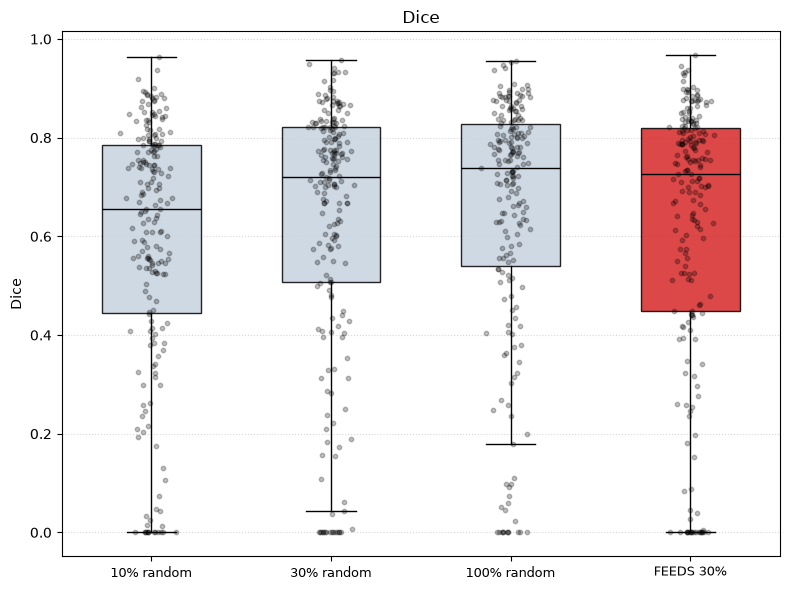

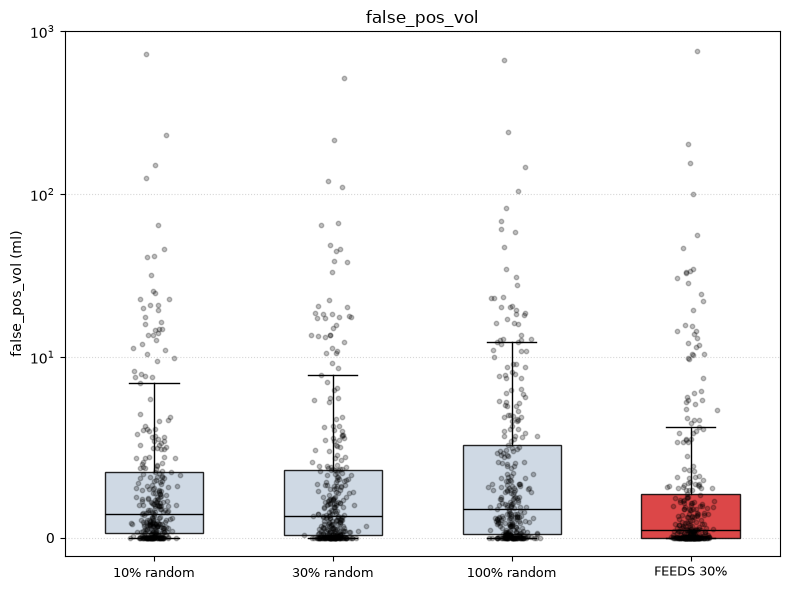

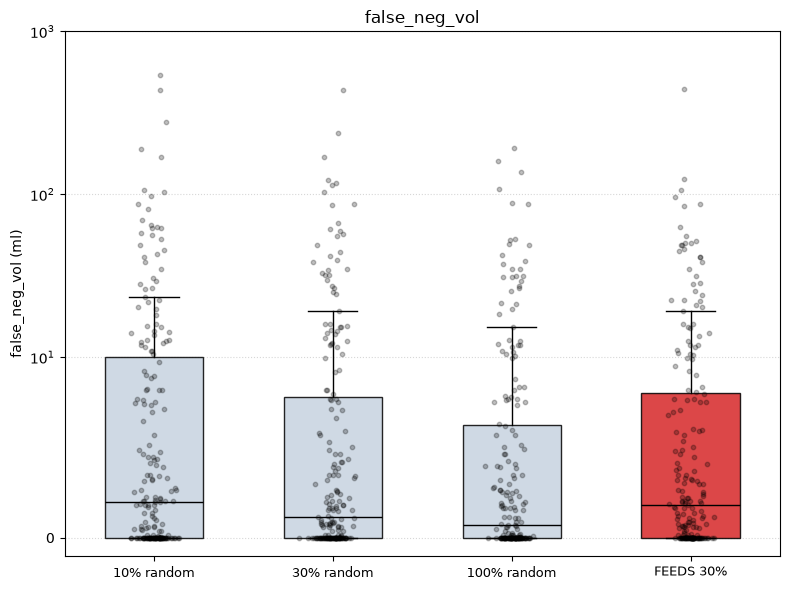

In [12]:
labels_map = {'fold_2': '10% random', 'fold_6': '30% random', 'fold_11': '100% random',
              'fold_4': 'FEEDS 30%'}

# stack FEEDS 30% with the random folds you want as context
random_context = random_cases[random_cases['fold'].isin(['fold_2', 'fold_6', 'fold_11'])]
feeds_30       = feeds_cases[feeds_cases['fold'] == 'fold_4']
combined       = pd.concat([random_context, feeds_30], ignore_index=True)
combined_dis   = combined[combined['diseased'] == True]

order     = ['fold_2', 'fold_6', 'fold_11', 'fold_4']   # FEEDS last
test_fold = 'fold_4'

plots = [
    (combined,     'Dice',          None,     None,        ''),
    (combined,     'false_pos_vol', 'symlog', (-1, 1000),  'ml'),
    (combined_dis, 'false_neg_vol', 'symlog', (-1, 1000),  'ml'),
]

for df, metric, yscale, ylim, unit in plots:
    present = [f for f in order if f in set(df['fold'])]
    data    = [df.loc[df['fold'] == f, metric].dropna().to_numpy() for f in present]
    labels  = [labels_map.get(f, f) for f in present]
    colors  = ['#d62728' if f == test_fold else '#c7d3e0' for f in present]

    fig, ax = plt.subplots(figsize=(8, 6))
    bp = ax.boxplot(data, patch_artist=True, widths=0.55, showfliers=False)
    for box, c in zip(bp['boxes'], colors):
        box.set_facecolor(c); box.set_alpha(0.85)
    for med in bp['medians']:
        med.set_color('black')
    for i, v in enumerate(data, start=1):
        ax.scatter(np.random.normal(i, 0.05, len(v)), v, s=10, color='black', alpha=0.25, zorder=3)

    ax.set_xticks(range(1, len(present) + 1))
    ax.set_xticklabels(labels, fontsize=9)
    if yscale == 'symlog':
        ax.set_yscale('symlog', linthresh=10)
    if ylim:
        ax.set_ylim(ylim)
    ax.set_ylabel(f'{metric} ({unit})' if unit else metric)
    ax.set_title(metric)
    ax.grid(axis='y', ls=':', alpha=0.5)
    plt.tight_layout()
    plt.show()